In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib

data = pd.read_csv(r'C:\Users\jayde\OneDrive\Desktop\Placement_Predictor\data\processed\cleaned_data.csv')
stores = pd.read_csv(r'C:\Users\jayde\OneDrive\Desktop\Placement_Predictor\data\raw\stores.csv')

stores['Type'] = stores['Type'].map({'A': 0, 'B': 1, 'C': 2})


data.columns.tolist()

['Store',
 'Dept',
 'Date',
 'Weekly_Sales',
 'IsHoliday',
 'Temperature',
 'Fuel_Price',
 'MarkDown1',
 'MarkDown2',
 'MarkDown3',
 'MarkDown4',
 'MarkDown5',
 'CPI',
 'Unemployment',
 'Type',
 'Size',
 'Week',
 'Month',
 'Year']

In [19]:
X = data.drop(columns=['Weekly_Sales', 'Date'])
y = data['Weekly_Sales']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
model = joblib.load(r'C:\Users\jayde\OneDrive\Desktop\Placement_Predictor\models\random_forest.pkl')

In [22]:
predictions = model.predict(X_test)
MAE = mean_absolute_error(y_test, predictions)
print(f'Mean Absolute Error: {MAE}')

Mean Absolute Error: 1445.143426917238


In [23]:
def recommend_department(store, is_holiday, temperature, fuel_price,
                            cpi, unemployment, week, month, year, stores_df):

      store_info = stores_df[stores_df['Store'] == store].iloc[0]

      departments = data['Dept'].unique()

      results = []
      for dept in departments:
          X_input = pd.DataFrame([{
              'Store': store,
              'Dept': dept,
              'Week': week,
              'Month': month,
              'Year': year,
              'IsHoliday': is_holiday,
              'Temperature': temperature,
              'Fuel_Price': fuel_price,
              'MarkDown1': 0, 'MarkDown2': 0, 'MarkDown3': 0,
              'MarkDown4': 0, 'MarkDown5': 0,
              'CPI': cpi,
              'Unemployment': unemployment,
              'Type': store_info['Type'],
              'Size': store_info['Size']
          }])
          X_input = X_input[X.columns]
          predicted_sales = model.predict(X_input)[0]
          results.append((dept, predicted_sales))

      results.sort(key=lambda x: x[1], reverse=True)
      return results[:5]

In [24]:
top_depts = recommend_department(
      store = 1,
      is_holiday = 0,
      temperature = 60,
      fuel_price = 3.5,
      cpi = 211,
      unemployment = 7.0,
      week = 1,
      month = 1,
      year = 2011,
      stores_df = stores
  )


print(f"{'Rank':<6} {'Department':<12} {'Predicted Sales'}")
print("-" * 35)
for rank, (dept, sales) in enumerate(top_depts, 1):
    print(f"{rank:<6} {'Dept ' + str(dept):<12} ${sales:,.2f}")

Rank   Department   Predicted Sales
-----------------------------------
1      Dept 92      $128,358.11
2      Dept 95      $114,081.08
3      Dept 38      $91,255.37
4      Dept 90      $76,893.55
5      Dept 93      $69,896.73


In [25]:
top_depts = recommend_department(
      store=1,
      is_holiday=1,
      temperature=35,
      fuel_price=3.5,
      cpi=211,
      unemployment=7.0,
      week=51,
      month=12,
      year=2011,
      stores_df=stores
  )



print(f"{'Rank':<6} {'Department':<12} {'Predicted Sales'}")
print("-" * 35)

for rank, (dept, sales) in enumerate(top_depts, 1):
    print(f"{rank:<6} {'Dept ' + str(dept):<12} ${sales:,.2f}")

Rank   Department   Predicted Sales
-----------------------------------
1      Dept 92      $149,285.19
2      Dept 7       $145,847.53
3      Dept 95      $111,601.48
4      Dept 72      $109,729.51
5      Dept 90      $93,020.30


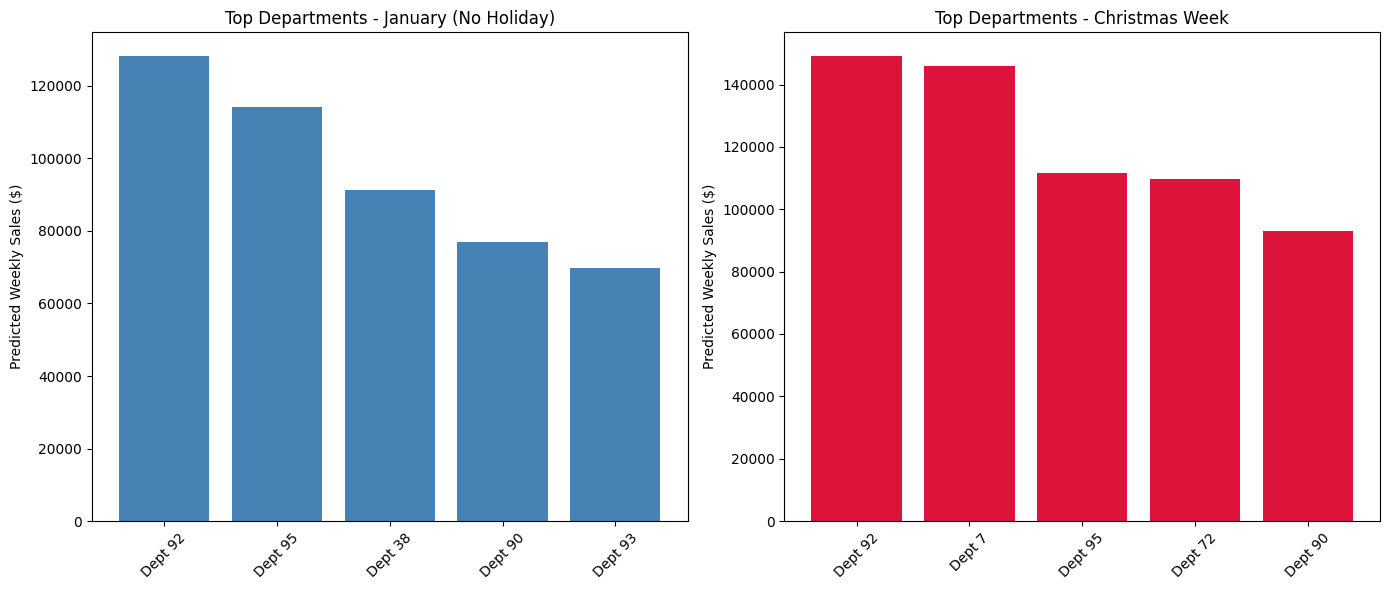

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

jan_depts = [92, 95, 38, 90, 93]
jan_sales = [128358, 114081, 91255, 76893, 69896]

xmas_depts = [92, 7, 95, 72, 90]
xmas_sales = [149285, 145847, 111601, 109729, 93020]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar([f'Dept {d}' for d in jan_depts], jan_sales, color='steelblue')
ax1.set_title('Top Departments - January (No Holiday)')
ax1.set_ylabel('Predicted Weekly Sales ($)')
ax1.tick_params(axis='x', rotation=45)

ax2.bar([f'Dept {d}' for d in xmas_depts], xmas_sales, color='crimson')
ax2.set_title('Top Departments - Christmas Week')
ax2.set_ylabel('Predicted Weekly Sales ($)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\Users\jayde\OneDrive\Desktop\Placement_Predictor\img\jan_vs_xmas.png')
plt.show()

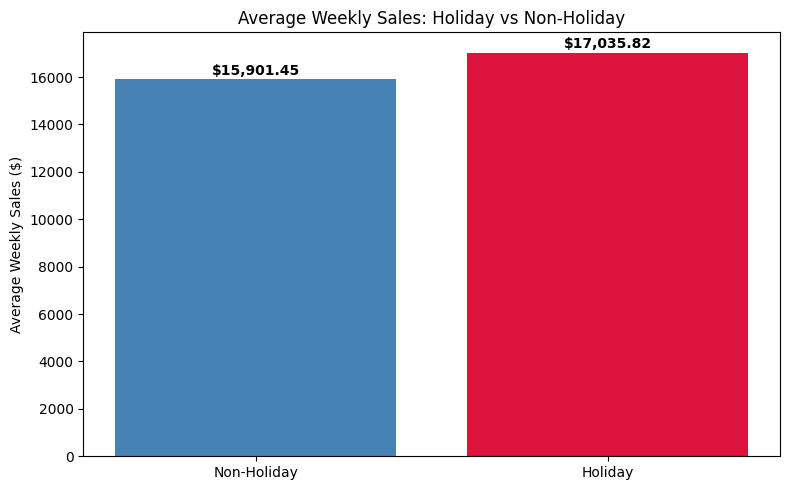

In [27]:
holiday_avg = data.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(['Non-Holiday', 'Holiday'], holiday_avg.values, color=['steelblue', 'crimson'])
plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.ylabel('Average Weekly Sales ($)')

for bar, value in zip(bars, holiday_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${value:,.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\jayde\OneDrive\Desktop\Placement_Predictor\img\holiday_vs_nonholiday.png')
plt.show()

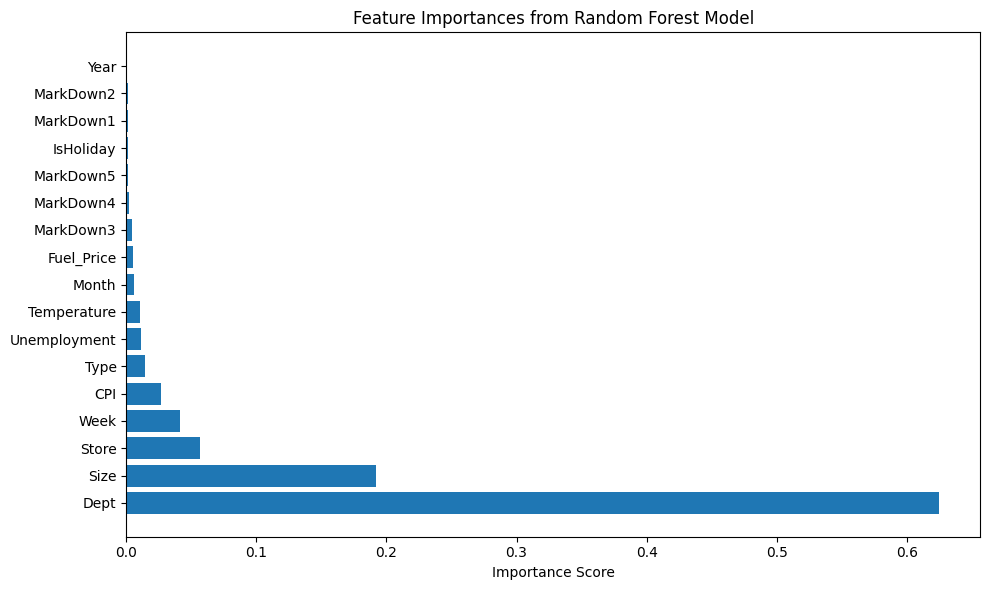

In [28]:
# model.feature_importance is an array the RF built during the training basically showing the weights per feature.
# pd.Series wraps the array into a Series with the feature names as index, then we sort it to see which features are most important.

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))

# importances.index gives the feature names, imporances.values gives the importance scores when then translate to the bar lengths
plt.barh(importances.index, importances.values)

plt.title('Feature Importances from Random Forest Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r'C:\Users\jayde\OneDrive\Desktop\Placement_Predictor\img\feature_importance.png')
plt.show()

In [29]:
import joblib

joblib.dump(model, r'C:\Users\jayde\OneDrive\Desktop\Placement_Predictor\models\random_forest.pkl')

['C:\\Users\\jayde\\OneDrive\\Desktop\\Placement_Predictor\\models\\random_forest.pkl']